# Notebook dedicated to build the directionality MC distributions on 2.2PPO with the SNO+ Style

In [1]:
import os
import glob
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

In [2]:
# Define las rutas relativas o absolutas en tu máquina local
read_dir = 'E:/Data/solars/mc/data_for_quick_plots/2p2PPO/'  # Ajusta a la carpeta donde descargaste los .npy
save_dir = 'C:/Users/joanc/jupyter_notebooks/Solar-Neutrinos-Project/mc data analysis/2p2PPO/figs/above_5_MeV/snop_style/'

os.makedirs(save_dir, exist_ok=True)

bins = 60
E_inf_cut = 5
t_res_cut_list = [(-3, 4), (-3, 3), (-3, 2), (-3, 1)]

bin_edges = np.linspace(-1.0, 1.0, bins + 1)
hist_data = {tres: np.zeros(bins) for tres in t_res_cut_list}

# Búsqueda de archivos
base_files = glob.glob(os.path.join(read_dir, 'cos_alpha_*.npy'))
indices = [os.path.basename(f).replace('cos_alpha_', '').replace('.npy', '') for f in base_files]

print(f'Procesando {len(indices)} chunks locales...')

for idx in indices:
    cos_chunk = np.load(os.path.join(read_dir, f'cos_alpha_{idx}.npy')).astype(np.float32)
    en_chunk = np.load(os.path.join(read_dir, f'energy_corr_{idx}.npy')).astype(np.float32)
    tres_chunk = np.load(os.path.join(read_dir, f'hit_residual_{idx}.npy')).astype(np.float32)

    # Corte de energía
    E_mask = en_chunk >= E_inf_cut
    cos_chunk = cos_chunk[E_mask]
    tres_chunk = tres_chunk[E_mask]

    # Histogramar por cortes de t_res
    for t_res_cut_i in t_res_cut_list:
        tres_mask = (tres_chunk >= t_res_cut_i[0]) & (tres_chunk <= t_res_cut_i[1])
        counts, _ = np.histogram(cos_chunk[tres_mask], bins=bin_edges)
        hist_data[t_res_cut_i] += counts

print('Datos listos para graficar.')

Procesando 7 chunks locales...
Datos listos para graficar.


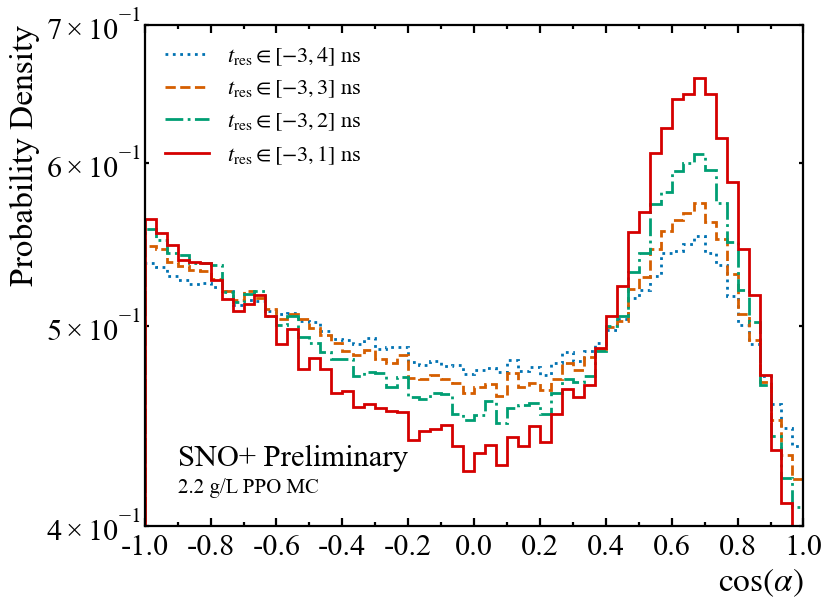

Figura exportada con éxito en: C:/Users/joanc/jupyter_notebooks/Solar-Neutrinos-Project/mc data analysis/2p2PPO/figs/above_5_MeV/snop_style/cos_alpha_dir_tres_cuts_2p2PPO_snop_style.pdf


In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ==========================================
# --- SNO+ Global Plot Settings (Nativo) ---
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

# Tamaños estándar de SNO+
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 22

plt.rcParams["xaxis.labellocation"] = 'right'
plt.rcParams["yaxis.labellocation"] = 'top'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 1.6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['xtick.minor.width'] = 1.6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.major.width'] = 1.6
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['ytick.minor.width'] = 1.6
plt.rcParams['axes.linewidth'] = 1.6
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.figsize'] = (8.5, 6.5)
plt.rcParams['xtick.major.pad'] = '6'
plt.rcParams['ytick.major.pad'] = '6'
plt.rcParams['axes.titlepad'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True

colors = ['#0072B2', '#D55E00', '#009E73', '#D50000']
linestyles = [':', '--', '-.', '-']
# ==========================================

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.minorticks_on()

for i, t_res_cut_i in enumerate(t_res_cut_list):
    counts = hist_data[t_res_cut_i]
    plt_label = rf'$t_{{\rm res}} \in [{t_res_cut_i[0]}, {t_res_cut_i[1]}]$ ns'

    ax.hist(
        bin_edges[:-1], 
        bins=bin_edges, 
        weights=counts, 
        density=True, 
        histtype='step', 
        linewidth=2.0, 
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        label=plt_label
    )

ax.set_yscale('log')
ax.set_xlabel(r'$\cos(\alpha)$', size=24)
ax.set_ylabel('Probability Density', size=24)
ax.set_xlim(-1, 1)
ax.set_ylim(0.4, 0.7)

# Locators de los ejes
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.xaxis.set_major_locator(MultipleLocator(0.2))

# Construir handles manuales tipo línea con los estilos exactos del plot
legend_handles = []
for i, t_res_cut_i in enumerate(t_res_cut_list):
  plt_label = rf'$t_{{\rm res}} \in [{t_res_cut_i[0]}, {t_res_cut_i[1]}]$ ns'
  line = Line2D(
      [0],
      [0],
      color=colors[i % len(colors)],
      linestyle=linestyles[i % len(linestyles)],
      linewidth=2.0,
      label=plt_label,
  )
  legend_handles.append(line)

# Pasarle los handles directamente a la leyenda sin marco
ax.legend(handles=legend_handles, loc='upper left', frameon=False, fontsize=16)

# Título
#ax.set_title(rf'Solar $^8$B-$\nu_e$ Directionality - 2.2 g/L PPO MC' + '\n' + 
#    rf'E $\geq$ {E_inf_cut} MeV & R $\leq$ 5.5 m', 
#    size=22, 
#    y=1.02)

# Marca de agua SNO+ Preliminary
ax.text(0.05, 0.12, "SNO+ Preliminary", transform=ax.transAxes, color='black', size=22)
ax.text(0.05, 0.065, "2.2 g/L PPO MC", transform=ax.transAxes, color='black', size=15)

# Guardar en PDF vectorial y mostrar en Jupyter
save_path = os.path.join(save_dir, 'cos_alpha_dir_tres_cuts_2p2PPO_snop_style.pdf')
plt.savefig(save_path, format='pdf', bbox_inches='tight')

plt.show()
print(f'Figura exportada con éxito en: {save_path}')